# 圖像分類數據集
:label:`sec_fashion_mnist`

(**MNIST數據集**) :cite:`LeCun.Bottou.Bengio.ea.1998`
(**是圖像分類中廣泛使用的數據集之一，但作為基準數據集過於簡單。
我們將使用類似但更複雜的Fashion-MNIST數據集**) :cite:`Xiao.Rasul.Vollgraf.2017`。


In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torchvision
from torch.utils import data
from torchvision import transforms

plt.rcParams['figure.figsize'] = (3.5, 2.5) 
plt.rcParams['savefig.dpi'] = 144 
plt.rcParams['figure.dpi'] = 144 

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## 讀取數據集

我們可以[**透過框架中的內建函數將Fashion-MNIST數據集下載並讀取到記憶體中**]。


In [3]:
# 透過ToTensor實例將圖像數據從PIL類型轉換成32位浮點數格式，
# 並除以255使得所有像素的數值均在0～1之間
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

100.0%


Extracting ../data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ../data/FashionMNIST/raw



100.0%


Extracting ../data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ../data/FashionMNIST/raw



100.0%


Extracting ../data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ../data/FashionMNIST/raw



100.0%

Extracting ../data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ../data/FashionMNIST/raw



Fashion-MNIST由10個類別的圖像組成，
每個類別由*訓練數據集*（train dataset）中的6000張圖像
和*測試數據集*（test dataset）中的1000張圖像組成。
因此，訓練集和測試集分別包含60000和10000張圖像。
測試數據集不會用於訓練，只用於評估模型性能。


In [4]:
len(mnist_train), len(mnist_test)

(60000, 10000)

每個輸入圖像的高度和寬度均為28像素。
數據集由灰度圖像組成，其通道數為1。
為了簡潔起見，本書將高度$h$像素、寬度$w$像素圖像的形狀記為$h \times w$或（$h$,$w$）。


In [5]:
mnist_train[0][0].shape

torch.Size([1, 28, 28])

[~~兩個可視化數據集的函數~~]

Fashion-MNIST中包含的10個類別，分別為t-shirt（T恤）、trouser（褲子）、pullover（套衫）、dress（連衣裙）、coat（外套）、sandal（涼鞋）、shirt（襯衫）、sneaker（運動鞋）、bag（包）和ankle boot（短靴）。
以下函數用於在數字標籤索引及其文本名稱之間進行轉換。


In [6]:
def get_fashion_mnist_labels(labels):  #@save
    """返回Fashion-MNIST數據集的文本標籤"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

我們現在可以創建一個函數來可視化這些樣本。


In [7]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):  #@save
    """繪製圖像列表"""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # 圖片張量
            ax.imshow(img.numpy())
        else:
            # PIL圖片
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

以下是訓練數據集中前[**幾個樣本的圖像及其相應的標籤**]。


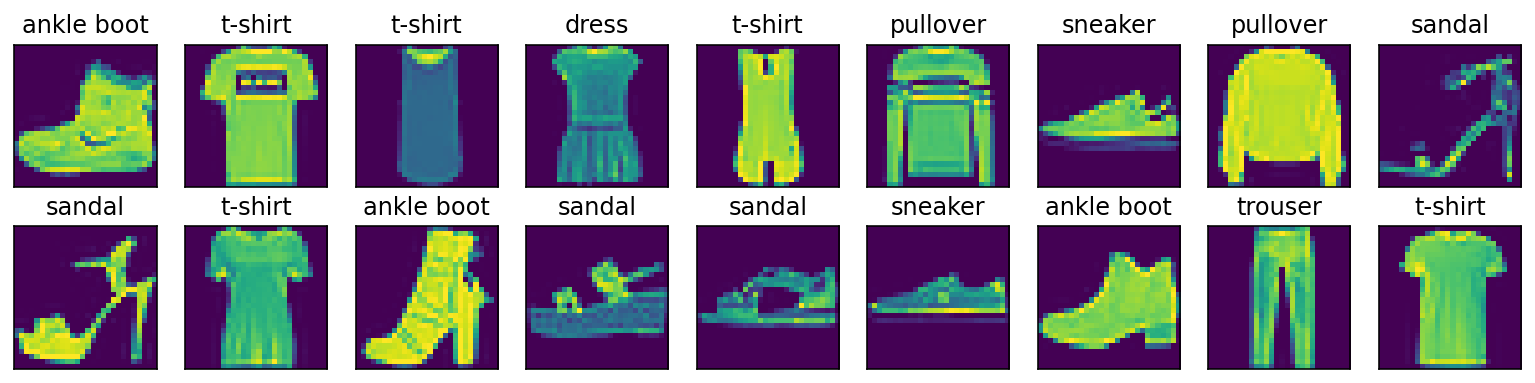

In [8]:
X, y = next(iter(data.DataLoader(mnist_train, batch_size=18)))
show_images(X.reshape(18, 28, 28), 2, 9, titles=get_fashion_mnist_labels(y));

## 讀取小批量

為了使我們在讀取訓練集和測試集時更容易，我們使用內置的數據迭代器，而不是從零開始創建。
回顧一下，在每次迭代中，數據加載器每次都[**讀取一小批量數據，大小為`batch_size`**]。
透過內置數據迭代器，我們可以隨機打亂所有樣本，從而無偏見地讀取小批量。


In [9]:
batch_size = 256

def get_dataloader_workers():  #@save
    """使用4個進程來讀取數據"""
    return 4

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True,
                             num_workers=get_dataloader_workers())

我們看一下讀取訓練數據所需時間。


In [10]:
import time

class Timer:  #@save
    """記錄多次運行時間"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """啟動計時器"""
        self.tik = time.time()

    def stop(self):
        """停止計時器並將時間記錄在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

# 使用 Timer
timer = Timer()
for X, y in train_iter:
    continue
f'{timer.stop():.2f} sec'

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


'12.63 sec'

In [11]:
timer = Timer()
for X, y in train_iter:
    continue
f'{timer.stop():.2f} sec'

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


'9.87 sec'

## 整合所有組件

現在我們[**定義`load_data_fashion_mnist`函數**]，用於獲取和讀取Fashion-MNIST數據集。
這個函數返回訓練集和驗證集的數據迭代器。
此外，這個函數還接受一個可選參數`resize`，用來將圖像大小調整為另一種形狀。


In [12]:
def load_data_fashion_mnist(batch_size, resize=None):  #@save
    """下載Fashion-MNIST數據集，然後將其加載到記憶體中"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=get_dataloader_workers()))

下面，我們透過指定`resize`參數來測試`load_data_fashion_mnist`函數的圖像大小調整功能。


In [13]:
train_iter, test_iter = load_data_fashion_mnist(32, resize=64)
for X, y in train_iter:
    print(X.shape, X.dtype, y.shape, y.dtype)
    break

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


我們現在已經準備好使用Fashion-MNIST數據集，以便在後續章節中調用來評估各種分類算法。

## 小結

* Fashion-MNIST是一個服裝分類數據集，由10個類別的圖像組成。我們將在後續章節中使用此數據集來評估各種分類算法。
* 我們將高度$h$像素，寬度$w$像素圖像的形狀記為$h \times w$或（$h$,$w$）。
* 數據迭代器是獲得更高性能的關鍵組件。依靠實現良好的數據迭代器，利用高性能計算來避免減慢訓練過程。

## 練習

1. 减少`batch_size`（如减少到1）是否會影響讀取性能？

    Answer: 會影響讀取性能，減少batch_size會增加讀取時間。

2. 數據迭代器的性能非常重要。當前的實現足夠快嗎？探索各種選擇來改進它。

    Answer: 當前的實現足夠快，但可以透過使用多個進程來加速讀取。

3. 查閱框架的線上API文檔。還有哪些其他數據集可用？

    Answer: 還有CIFAR-10、ImageNet等數據集可用。


[Discussions](https://discuss.d2l.ai/t/1787)
